In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [2]:
# =========================================
# COLUMN NAMES
# =========================================

column_names = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'
]

In [3]:
# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv(
    "adult.csv",
    names=column_names
)

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

FIRST 5 ROWS
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-

In [4]:
# =========================================
# (m) DATA CLEANING
# =========================================

# Replace ? with NaN
df.replace(" ?", np.nan, inplace=True)

# Check missing values
print("\nMISSING VALUES")
print(df.isnull().sum())

# Remove missing values
df_cleaned = df.dropna()

# Remove negative values from numeric columns
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns

df_cleaned = df_cleaned[
    (df_cleaned[numeric_cols] >= 0).all(axis=1)
]

print("\nSHAPE AFTER CLEANING")
print(df_cleaned.shape)



MISSING VALUES
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

SHAPE AFTER CLEANING
(30162, 15)


In [5]:
# =========================================
# (n) ERROR CORRECTING
# OUTLIER DETECTION & REMOVAL
# =========================================

def remove_outliers_iqr(df, columns):

    for col in columns:

        Q1 = df[col].quantile(0.25)

        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR

        upper = Q3 + 1.5 * IQR

        df = df[
            (df[col] >= lower) &
            (df[col] <= upper)
        ]

    return df

# Columns used for outlier removal
outlier_cols = [
    'age',
    'fnlwgt',
    'education_num',
    'hours_per_week'
]

df_no_outliers = remove_outliers_iqr(
    df_cleaned,
    outlier_cols
)

print("\nSHAPE AFTER OUTLIER REMOVAL")
print(df_no_outliers.shape)



SHAPE AFTER OUTLIER REMOVAL
(21330, 15)


In [6]:
# =========================================
# (o) DATA TRANSFORMATION
# LABEL ENCODING + FEATURE SCALING
# =========================================

# Label Encoding for categorical columns

label_encoder = LabelEncoder()

categorical_cols = df_no_outliers.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:

    df_no_outliers[col] = label_encoder.fit_transform(
        df_no_outliers[col]
    )

# Features and target

X = df_no_outliers.drop('income', axis=1)

y = df_no_outliers['income']

# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Display transformed dataset

df_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nTRANSFORMED DATASET")
print(df_scaled.head())


TRANSFORMED DATASET
        age  workclass    fnlwgt  education  education_num  marital_status  \
0  0.017734   3.025215 -1.186443  -0.394982       1.152322        1.023730   
1 -0.066643  -0.153287  0.397749   0.239070      -0.495342       -1.667440   
2  1.199011  -0.153287  0.616517  -2.614164      -1.319174       -0.321855   
3 -0.910413  -0.153287  1.805699  -0.394982       1.152322       -0.321855   
4 -0.151020  -0.153287  1.188365   0.556096       1.564238       -0.321855   

   occupation  relationship      race       sex  capital_gain  capital_loss  \
0   -1.412319     -0.216452  0.390231  0.670699      0.174441      -0.22132   
1   -0.181078     -0.216452  0.390231  0.670699     -0.149447      -0.22132   
2   -0.181078     -0.841289 -1.972423  0.670699     -0.149447      -0.22132   
3    0.803914      2.282895 -1.972423 -1.490982     -0.149447      -0.22132   
4   -0.673574      2.282895  0.390231 -1.490982     -0.149447      -0.22132   

   hours_per_week  native_country  

In [7]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# (p) LOGISTIC REGRESSION MODEL
# =========================================

logreg = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

logreg_acc = accuracy_score(
    y_test,
    y_pred_logreg
)

# =========================================
# NAIVE BAYES MODEL
# =========================================

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_acc = accuracy_score(
    y_test,
    y_pred_nb
)



LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      3144
           1       0.54      0.74      0.62      1122

    accuracy                           0.76      4266
   macro avg       0.71      0.76      0.72      4266
weighted avg       0.80      0.76      0.77      4266


NAIVE BAYES REPORT
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      3144
           1       0.69      0.34      0.45      1122

    accuracy                           0.78      4266
   macro avg       0.74      0.64      0.66      4266
weighted avg       0.77      0.78      0.76      4266



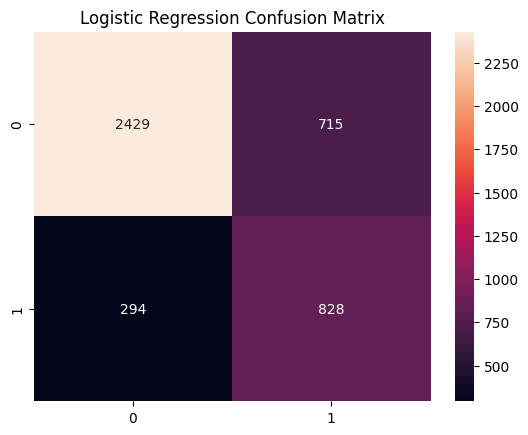

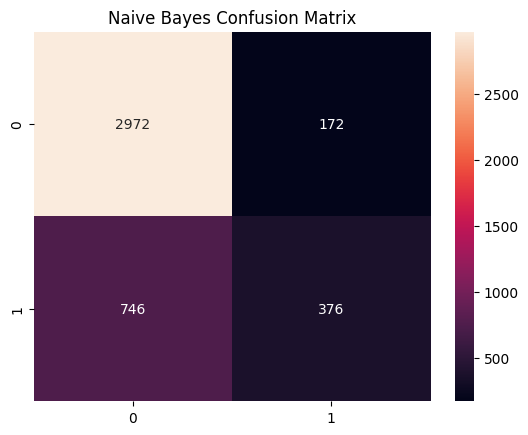

In [8]:
# =========================================
# CLASSIFICATION REPORTS
# =========================================

print("\n================================")
print("LOGISTIC REGRESSION REPORT")
print("================================")

print(classification_report(
    y_test,
    y_pred_logreg
))

print("\n================================")
print("NAIVE BAYES REPORT")
print("================================")

print(classification_report(
    y_test,
    y_pred_nb
))

# =========================================
# CONFUSION MATRIX VISUALIZATION
# LOGISTIC REGRESSION
# =========================================

sns.heatmap(
    confusion_matrix(y_test, y_pred_logreg),
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# =========================================
# CONFUSION MATRIX VISUALIZATION
# NAIVE BAYES
# =========================================

sns.heatmap(
    confusion_matrix(y_test, y_pred_nb),
    annot=True,
    fmt='d'
)

plt.title("Naive Bayes Confusion Matrix")

plt.show()


In [9]:
# =========================================
# FINAL COMPARISON
# =========================================

print("\n================================")
print("FINAL COMPARISON")
print("================================")

if logreg_acc > nb_acc:

    print("\nLogistic Regression Performs Better")

else:

    print("\nNaive Bayes Performs Better")


FINAL COMPARISON

Naive Bayes Performs Better
